# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [3]:
dataset = pd.read_csv("cancer.csv")
dataset.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [5]:
 dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,699.0,1.071704e+06,617095.729819,61634.0,870688.5,1171710.0,1238298.0,13454352.0
ClumpThickness,699.0,4.417740e+00,2.815741,1.0,2.0,4.0,6.0,10.0
Cell Size,699.0,3.134478e+00,3.051459,1.0,1.0,1.0,5.0,10.0
Cell Shape,699.0,3.207439e+00,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,699.0,2.806867e+00,2.855379,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,699.0,3.216023e+00,2.214300,1.0,2.0,2.0,4.0,10.0
Normal Nucleoli,699.0,3.437768e+00,2.438364,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,699.0,2.866953e+00,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413e+00,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,2.689557e+00,0.951273,2.0,2.0,2.0,4.0,4.0


In [6]:
dataset.shape

(699, 11)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [8]:
# We could see "?" values in column, this should be removed from data set
# Check for missing value in any other column

In [9]:
dataset.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [10]:
# No missing values found. So let us try to remove ? from bare nuclei column
# Get count of rows having ?

In [11]:
dataset['Bare Nuclei'].value_counts()

1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: Bare Nuclei, dtype: int64

In [12]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [13]:
dataset = dataset.replace('?', np.nan)
dataset = dataset.apply(lambda x: x.fillna(x.median()),axis=0)

In [14]:
dataset=dataset.drop_duplicates()
dataset.shape

(691, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [15]:
# Check for correlation of variable

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null object
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(10), object(1)
memory usage: 64.8+ KB


In [17]:
dataset['Bare Nuclei']=dataset['Bare Nuclei'].astype('float64')

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null float64
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: float64(1), int64(10)
memory usage: 64.8 KB


In [19]:
dataset.corr()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1.000000,-0.059165,-0.043273,-0.042184,-0.066230,-0.047642,-0.091235,-0.059645,-0.054001,-0.036001,-0.079459
ClumpThickness,-0.059165,1.000000,0.643340,0.653752,0.487949,0.517448,0.590841,0.561076,0.535712,0.350354,0.716938
Cell Size,-0.043273,0.643340,1.000000,0.905420,0.713117,0.747111,0.684791,0.759525,0.727239,0.460064,0.817720
Cell Shape,-0.042184,0.653752,0.905420,1.000000,0.690989,0.714393,0.704382,0.738455,0.724693,0.440592,0.817693
Marginal Adhesion,-0.066230,0.487949,0.713117,0.690989,1.000000,0.608477,0.672719,0.669813,0.602453,0.417167,0.701371
Single Epithelial Cell Size,-0.047642,0.517448,0.747111,0.714393,0.608477,1.000000,0.580709,0.620518,0.634058,0.482644,0.681233
Bare Nuclei,-0.091235,0.590841,0.684791,0.704382,0.672719,0.580709,1.000000,0.672687,0.578417,0.343020,0.816787
Normal Nucleoli,-0.059645,0.561076,0.759525,0.738455,0.669813,0.620518,0.672687,1.000000,0.669059,0.343821,0.756618
Bland Chromatin,-0.054001,0.535712,0.727239,0.724693,0.602453,0.634058,0.578417,0.669059,1.000000,0.427644,0.715540
Mitoses,-0.036001,0.350354,0.460064,0.440592,0.417167,0.482644,0.343020,0.343821,0.427644,1.000000,0.424111


In [20]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [21]:
#Let us check for pair plots

/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


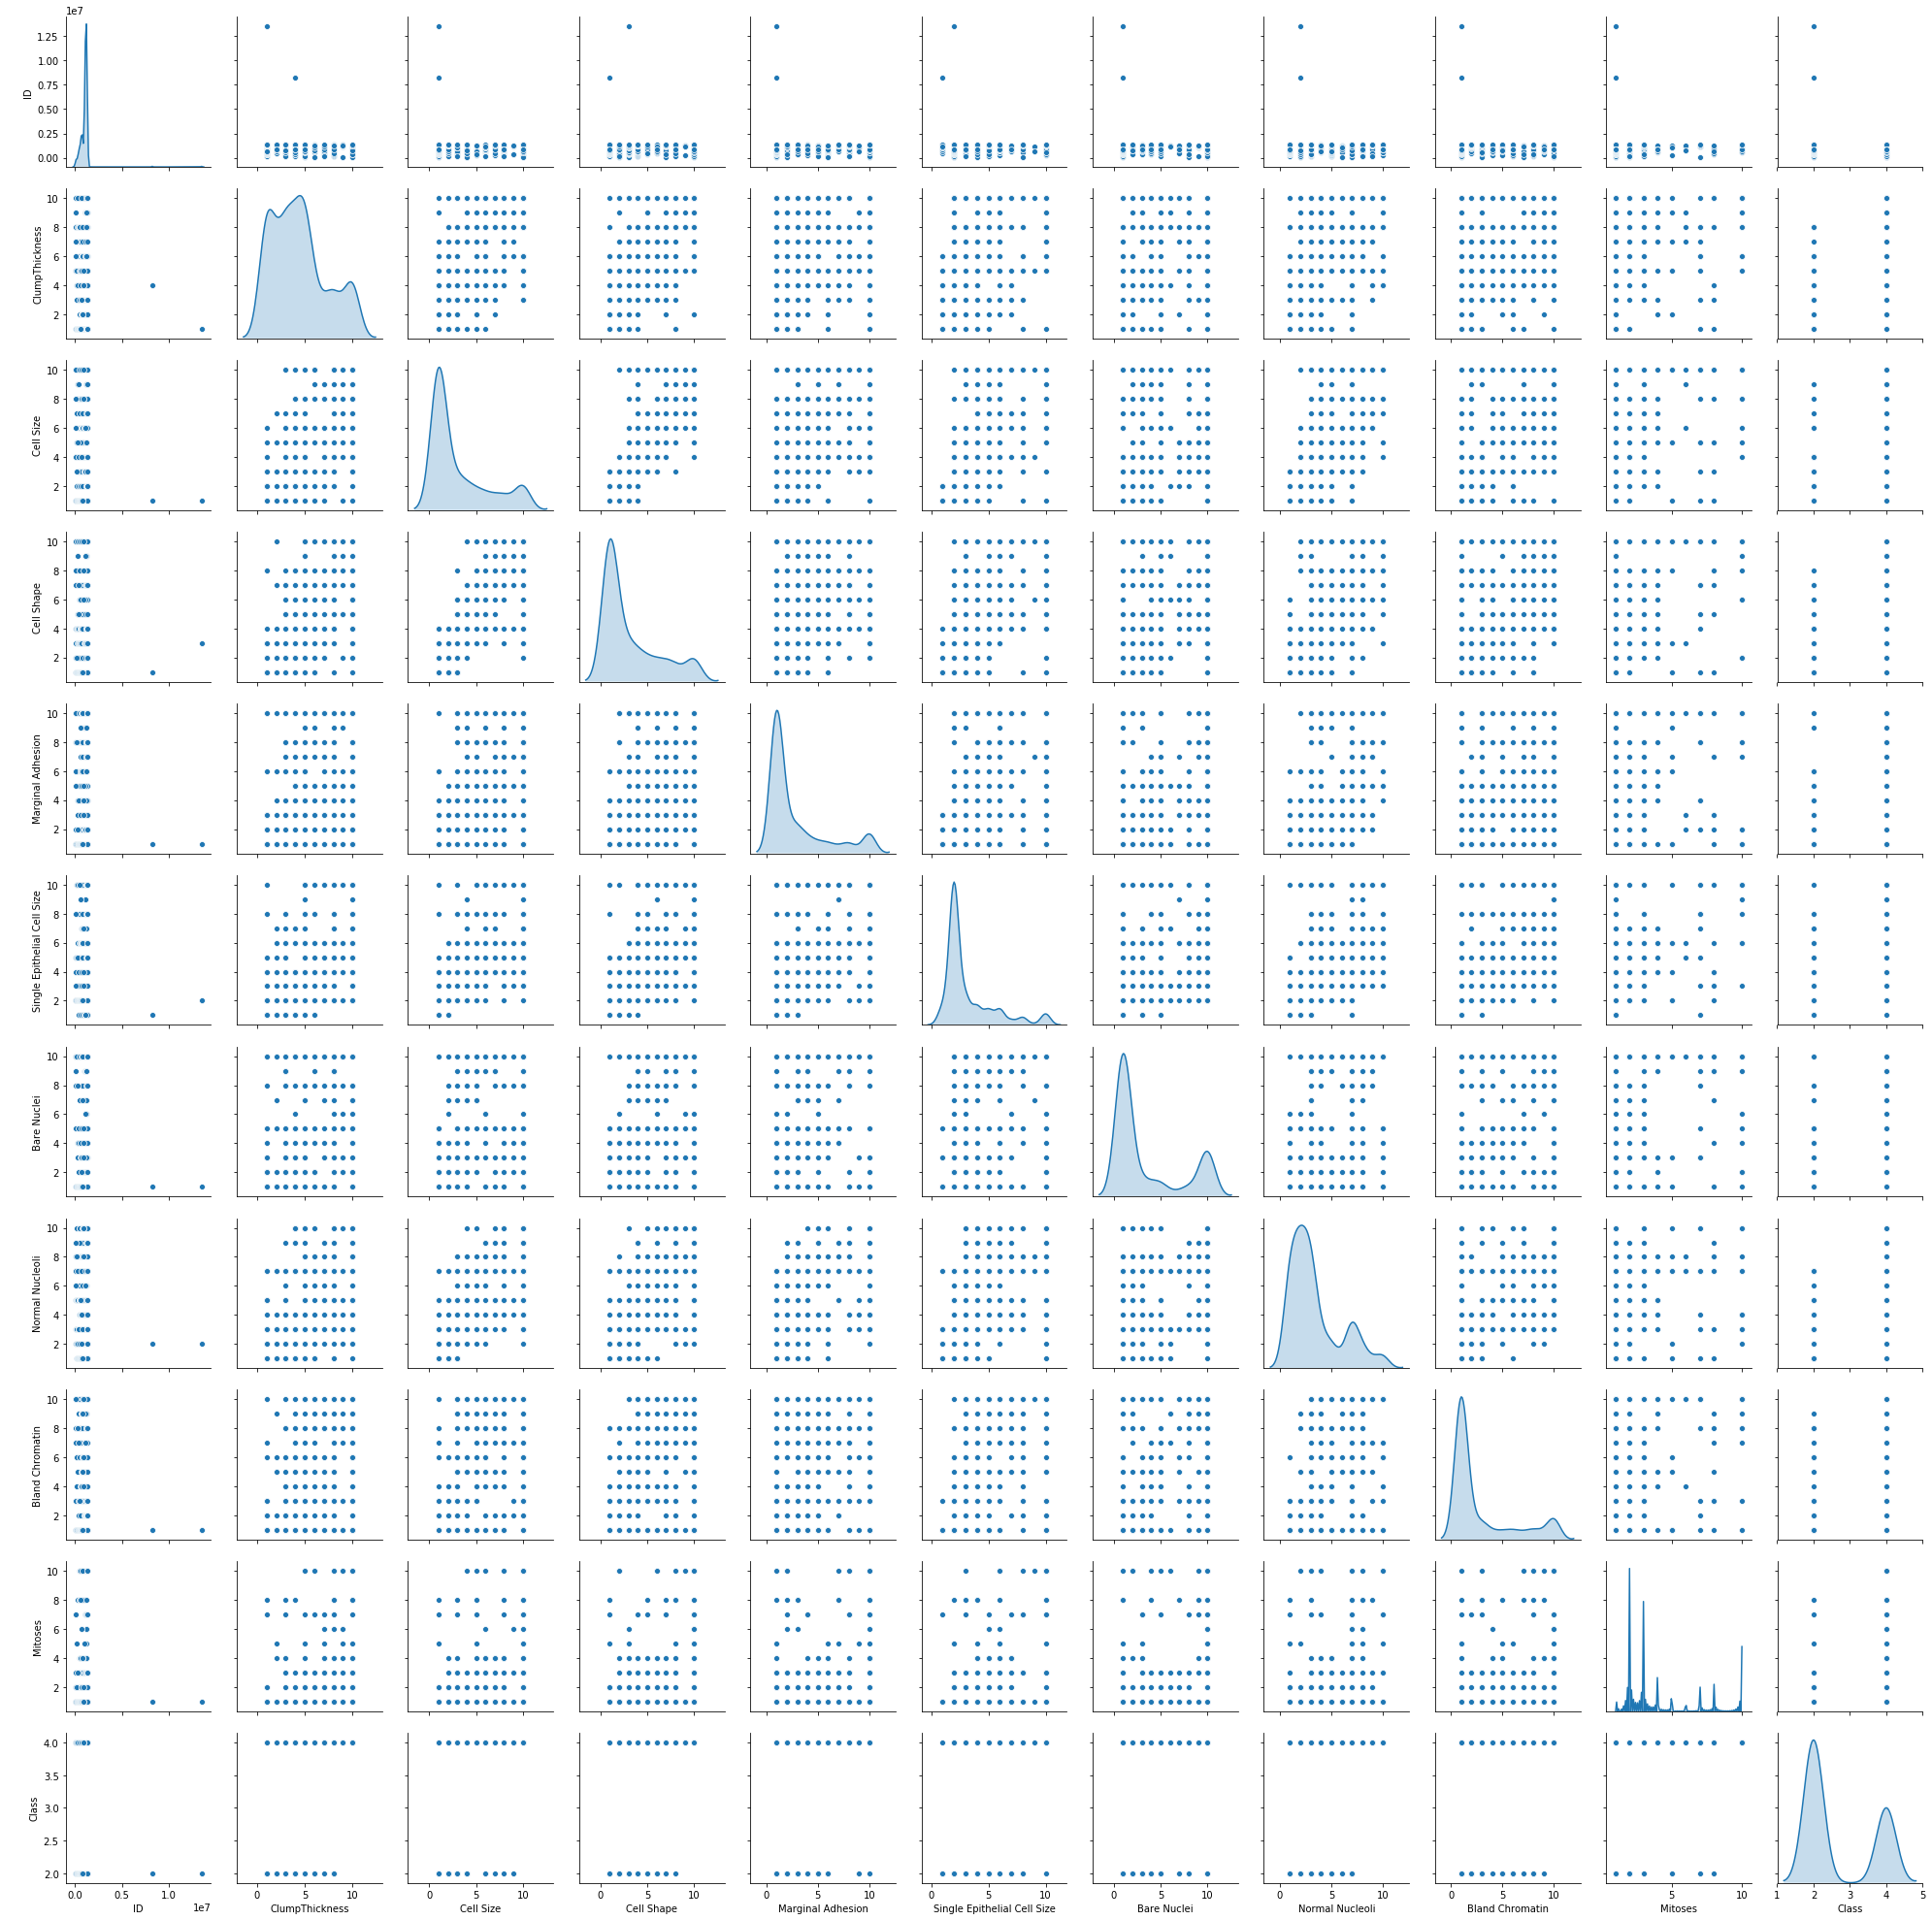

In [22]:
sns.pairplot(dataset,diag_kind='kde')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [23]:
# We could see most of the outliers are now removed.

In [24]:
ID = dataset['ID']
dataset = dataset.drop('ID', axis=1)
dataset.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null float64
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: float64(1), int64(9)
memory usage: 79.4 KB


In [26]:
X= dataset.drop("Class", axis=1)
Y=dataset['Class']

In [27]:
sc = StandardScaler()
X_std =  sc.fit_transform(X)          

/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/anaconda3/lib/python3.7/site-packages/sklearn/base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q6 Create a covariance matrix for identifying Principal components

In [28]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00144928 0.64427196 0.65469961 0.48865637 0.51819771 0.59169728
  0.56188952 0.53648819 0.35086138]
 [0.64427196 1.00144928 0.90673173 0.71415051 0.74819397 0.68578334
  0.760626   0.72829333 0.46073106]
 [0.65469961 0.90673173 1.00144928 0.69199047 0.71542879 0.7054026
  0.73952487 0.72574349 0.44123095]
 [0.48865637 0.71415051 0.69199047 1.00144928 0.60935911 0.67369366
  0.67078345 0.6033266  0.41777184]
 [0.51819771 0.74819397 0.71542879 0.60935911 1.00144928 0.58155073
  0.62141694 0.63497707 0.48334351]
 [0.59169728 0.68578334 0.7054026  0.67369366 0.58155073 1.00144928
  0.67366165 0.57925498 0.34351675]
 [0.56188952 0.760626   0.73952487 0.67078345 0.62141694 0.67366165
  1.00144928 0.67002891 0.34431924]
 [0.53648819 0.72829333 0.72574349 0.6033266  0.63497707 0.57925498
  0.67002891 1.00144928 0.42826329]
 [0.35086138 0.46073106 0.44123095 0.41777184 0.48334351 0.34351675
  0.34431924 0.42826329 1.00144928]]


# Q7 Identify eigen values and eigen vector

In [29]:
# Step 2- Get eigen values and eigen vector

In [32]:
# PCA
# Step 1 - Create covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n', eigenvectors)
print('\n Eigen Values \n', eigenvalues)

Eigen Vectors 
 [[-0.30205422  0.14897227 -0.86876767 -0.00255044 -0.02886788  0.26683317
  -0.19324853 -0.14973061 -0.00303072]
 [-0.38087763  0.04836887  0.03660386 -0.73666757  0.1895303  -0.44033376
  -0.23370998  0.09452526  0.12329959]
 [-0.3772005   0.08333656 -0.02037545  0.66434556  0.16758725 -0.58989507
  -0.15107072  0.06055041  0.08033821]
 [-0.33432944  0.05023264  0.39016444  0.04590585 -0.48698947  0.19616967
  -0.4894843  -0.46460377 -0.01649364]
 [-0.33590135 -0.1737774   0.15769698  0.06655255  0.32869726  0.39056782
   0.2106072  -0.06514068  0.72006271]
 [-0.33287375  0.2470288  -0.02956386 -0.07104864 -0.55678398 -0.15832954
   0.69557935  0.0163597   0.05545258]
 [-0.34640353  0.22999253  0.18339467  0.06246875  0.00969919  0.39437394
  -0.13201328  0.73915875 -0.26488494]
 [-0.33648572 -0.02063119  0.13579984 -0.02017884  0.47669866  0.11577424
   0.31537662 -0.40981256 -0.59954057]
 [-0.22975288 -0.90634176 -0.11593909  0.00808282 -0.22937896 -0.04360687
   0.0

In [33]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.909542747208758, array([-0.30205422, -0.38087763, -0.3772005 , -0.33432944, -0.33590135,
       -0.33287375, -0.34640353, -0.33648572, -0.22975288])), (0.7768874845839754, array([ 0.14897227,  0.04836887,  0.08333656,  0.05023264, -0.1737774 ,
        0.2470288 ,  0.22999253, -0.02063119, -0.90634176])), (0.5406255626037697, array([-0.86876767,  0.03660386, -0.02037545,  0.39016444,  0.15769698,
       -0.02956386,  0.18339467,  0.13579984, -0.11593909])), (0.4661373412132912, array([-0.02886788,  0.1895303 ,  0.16758725, -0.48698947,  0.32869726,
       -0.55678398,  0.00969919,  0.47669866, -0.22937896])), (0.3706809145606778, array([-0.00303072,  0.12329959,  0.08033821, -0.01649364,  0.72006271,
        0.05545258, -0.26488494, -0.59954057, -0.163962  ])), (0.3017105184835335, array([-0.19324853, -0.23370998, -0.15107072, -0.4894843 ,  0.2106072 ,
        0.69557935, -0.13201328,  0.31537662,  0.0232693 ])), (0.2936126705582533, array([-0.14973061,  0.09452526,  0.06055041, -0.

# Q8 Find variance and cumulative variance by each eigen vector

In [35]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n', eig_vecs)
print('\n Eigen Values \n', eig_vals)

Eigen Vectors 
 [[-0.30205422  0.14897227 -0.86876767 -0.00255044 -0.02886788  0.26683317
  -0.19324853 -0.14973061 -0.00303072]
 [-0.38087763  0.04836887  0.03660386 -0.73666757  0.1895303  -0.44033376
  -0.23370998  0.09452526  0.12329959]
 [-0.3772005   0.08333656 -0.02037545  0.66434556  0.16758725 -0.58989507
  -0.15107072  0.06055041  0.08033821]
 [-0.33432944  0.05023264  0.39016444  0.04590585 -0.48698947  0.19616967
  -0.4894843  -0.46460377 -0.01649364]
 [-0.33590135 -0.1737774   0.15769698  0.06655255  0.32869726  0.39056782
   0.2106072  -0.06514068  0.72006271]
 [-0.33287375  0.2470288  -0.02956386 -0.07104864 -0.55678398 -0.15832954
   0.69557935  0.0163597   0.05545258]
 [-0.34640353  0.22999253  0.18339467  0.06246875  0.00969919  0.39437394
  -0.13201328  0.73915875 -0.26488494]
 [-0.33648572 -0.02063119  0.13579984 -0.02017884  0.47669866  0.11577424
   0.31537662 -0.40981256 -0.59954057]
 [-0.22975288 -0.90634176 -0.11593909  0.00808282 -0.22937896 -0.04360687
   0.0

In [36]:
print("Eigen Values:")
pd.DataFrame(eig_vals).transpose()

Eigen Values:


,0,1,2,3,4,5,6,7,8
0,5.909543,0.776887,0.540626,0.090404,0.466137,0.263442,0.301711,0.293613,0.370681


In [37]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

In [38]:
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 65.56656208  74.18615308  80.18441065  85.35621906  89.46893543
  92.8164231   96.07406488  98.99695992 100.        ]


In [39]:
var_exp

[65.56656207708711,
 8.619591001172914,
 5.9982575686863076,
 5.171808416741779,
 4.112716369944814,
 3.3474876628660284,
 3.2576417862227847,
 2.922895034252795,
 1.003040083025478]

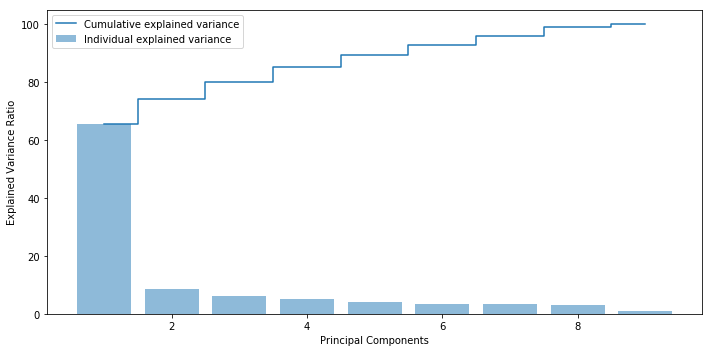

In [40]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
pca.fit(X)  

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [42]:
pca.transform(X)

array([[-4.42359951e+00,  2.63651841e-03, -1.75263332e+00, ...,
        -1.05397680e+00, -5.11040921e-03, -1.01312367e-02],
       [ 4.84125405e+00, -4.87133117e+00,  1.17262032e+00, ...,
         2.58063278e-01,  3.15824756e+00, -2.35308745e-02],
       [-4.58088161e+00, -6.23482479e-01,  5.33320783e-02, ...,
        -9.43776843e-01, -1.97881868e-01,  3.35489513e-02],
       ...,
       [ 1.03275588e+01,  7.30159884e+00,  4.66741198e-01, ...,
        -2.02197242e-01, -1.28071204e-01, -2.14800361e-01],
       [ 6.46844346e+00,  2.58858205e+00,  1.65978412e+00, ...,
        -2.36325860e+00, -2.19997170e+00,  1.19716582e+00],
       [ 7.55169793e+00,  1.26773425e+00,  1.94628799e+00, ...,
        -2.02835708e+00, -1.87657435e+00, -2.88226321e-01]])

In [43]:
pca.components_

array([[ 0.29789512,  0.40289967,  0.39040652,  0.33488425,  0.24788168,
         0.43850814,  0.29320962,  0.35941632,  0.12441443],
       [-0.07832781,  0.22830427,  0.16908724, -0.10691954,  0.18578972,
        -0.78277462,  0.02279283,  0.47755892,  0.16088402],
       [-0.85684049, -0.01508696, -0.06619668,  0.47574536,  0.06563585,
         0.09228441,  0.09793185,  0.10738419,  0.03057155],
       [ 0.1134942 ,  0.26033339,  0.17336755,  0.43812395,  0.17216544,
        -0.32754078, -0.0392299 , -0.7281552 ,  0.1693039 ],
       [ 0.35752898, -0.38038003, -0.41007428,  0.56117948, -0.10200984,
        -0.1042805 , -0.17325417,  0.27210388,  0.34505475],
       [-0.14514141, -0.0106004 , -0.00510392, -0.31265966,  0.43164658,
         0.24980549, -0.43509831, -0.04827128,  0.66383528],
       [-0.02988963,  0.18225125,  0.36080448,  0.18156395, -0.3284573 ,
         0.05042069, -0.78743374,  0.14511739, -0.22629262],
       [ 0.0907585 , -0.10451095, -0.20285575,  0.1041613 ,  0

In [44]:
print(pca.explained_variance_ratio_)

[0.68971815 0.07360141 0.0608671  0.04434708 0.03724012 0.03483165
 0.02529823 0.02259188 0.01150438]


In [45]:
print(pca.singular_values_)  

[183.04764943  59.79589644  54.37754813  46.41526634  42.53376794
  41.13536441  35.05689222  33.12871053  23.64068166]


# Q10 Find correlation between components and features

In [46]:
pca_df=pd.DataFrame(pca.components_)

/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


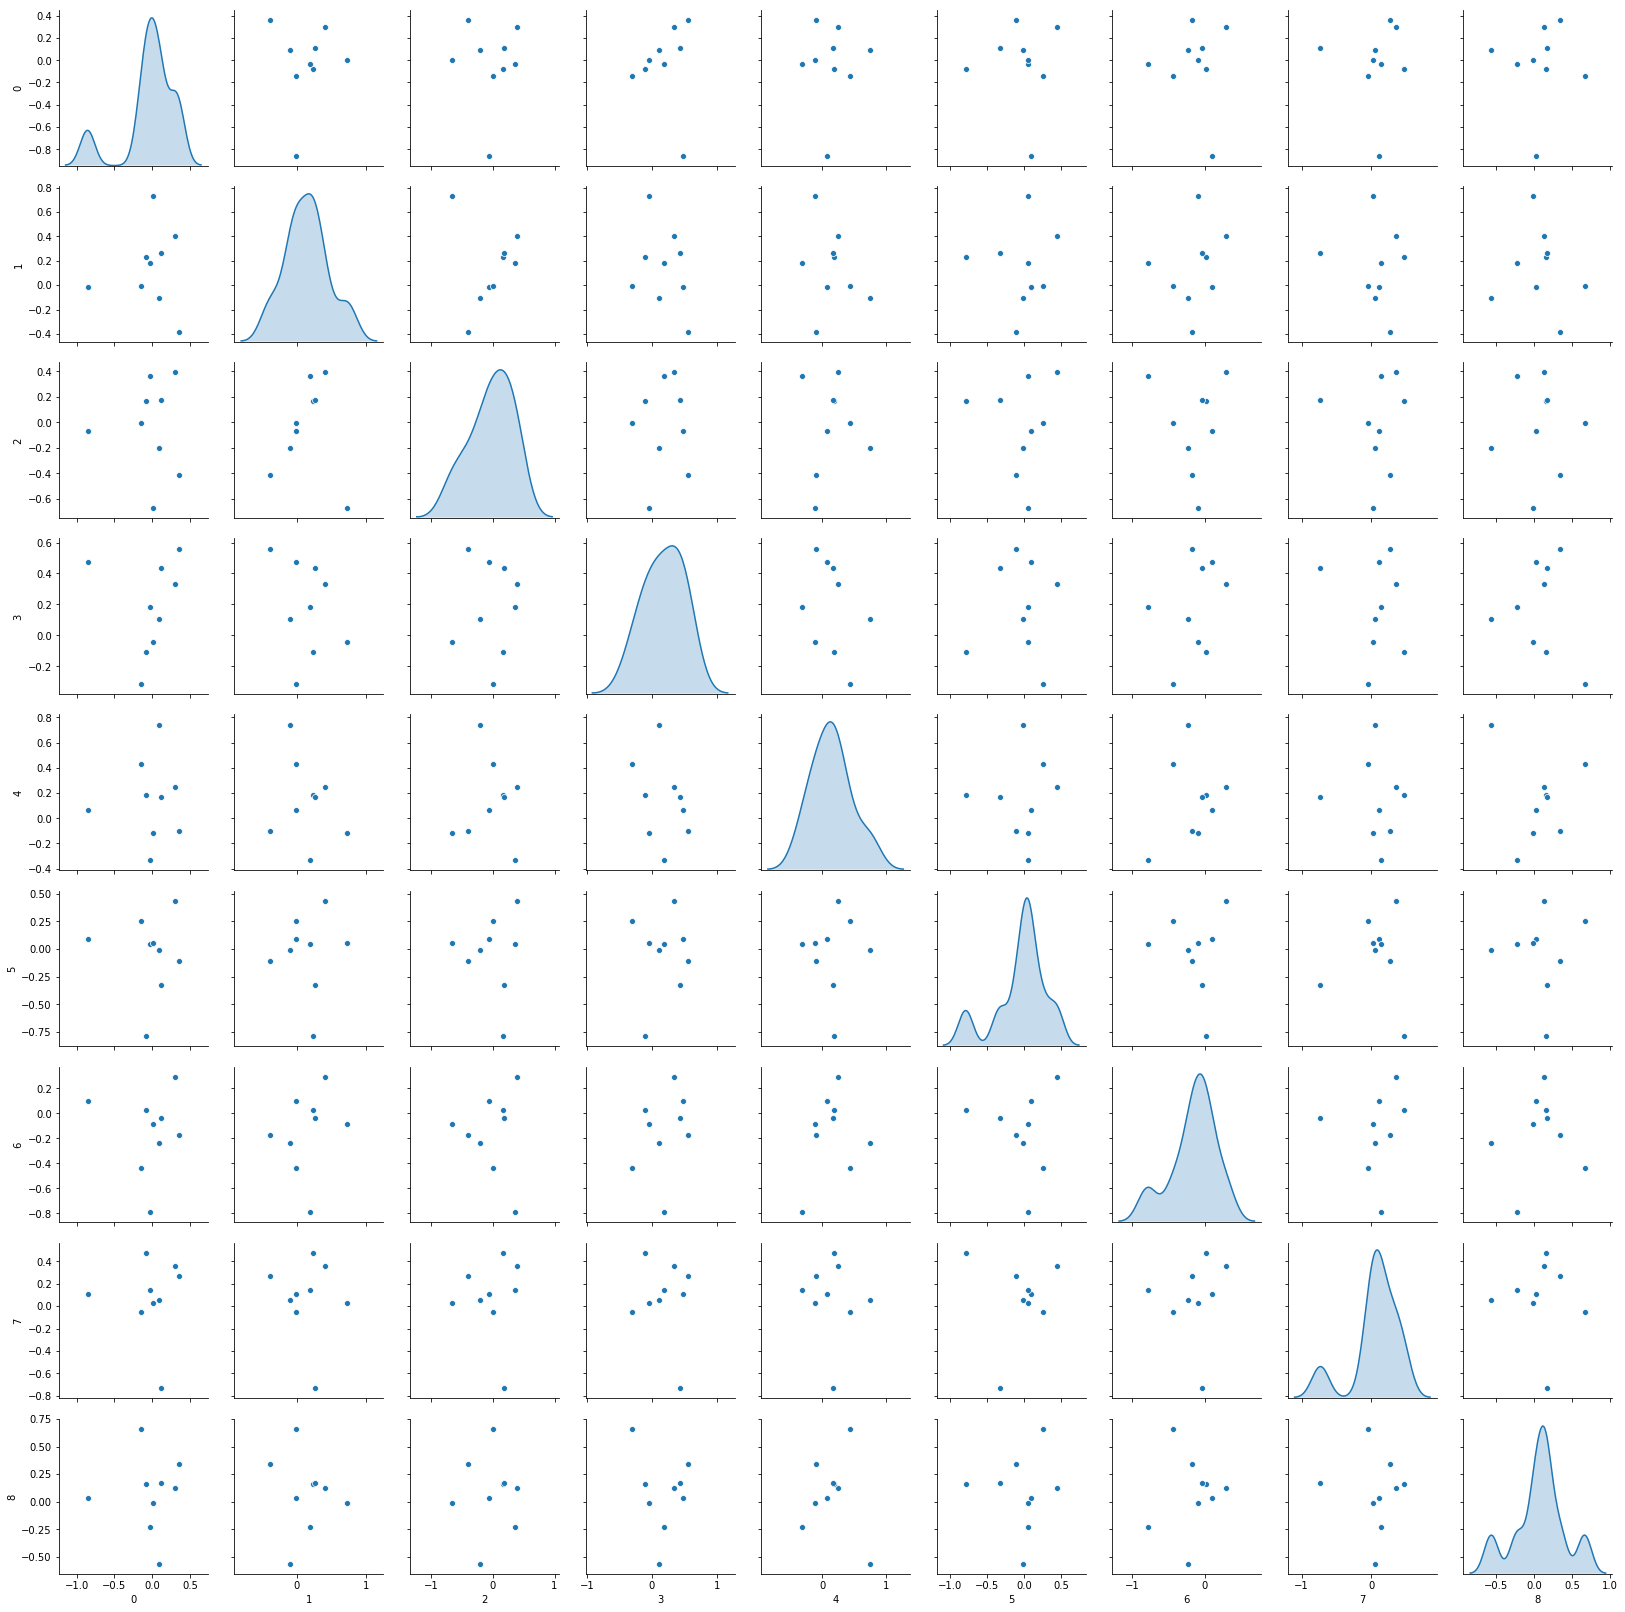

In [47]:
sns.pairplot(pca_df,diag_kind='kde')

In [48]:
pca_df.corr()

,0,1,2,3,4,5,6,7,8
0,1.000000,0.038868,-0.007034,0.053059,0.039306,-0.009251,-0.040865,0.018561,0.019293
1,0.038868,1.000000,0.041071,-0.309823,-0.229515,0.054020,0.238618,-0.108384,-0.112654
2,-0.007034,0.041071,1.000000,0.056066,0.041534,-0.009775,-0.043181,0.019613,0.020386
3,0.053059,-0.309823,0.056066,1.000000,-0.313315,0.073743,0.325741,-0.147956,-0.153786
4,0.039306,-0.229515,0.041534,-0.313315,1.000000,0.054628,0.241307,-0.109605,-0.113924
5,-0.009251,0.054020,-0.009775,0.073743,0.054628,1.000000,-0.056795,0.025797,0.026814
6,-0.040865,0.238618,-0.043181,0.325741,0.241307,-0.056795,1.000000,0.113952,0.118442
7,0.018561,-0.108384,0.019613,-0.147956,-0.109605,0.025797,0.113952,1.000000,-0.053798
8,0.019293,-0.112654,0.020386,-0.153786,-0.113924,0.026814,0.118442,-0.053798,1.000000
